<a href="https://colab.research.google.com/github/bonnandrei24/Statistical-Theory-Buenaventura-Repository/blob/main/FA9_Problems4and5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== Problem 4 ==========
                    mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
rownames                                                                     
Mazda RX4          21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
Mazda RX4 Wag      21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
Datsun 710         22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
Hornet 4 Drive     21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

                   carb  
rownames                 
Mazda RX4             4  
Mazda RX4 Wag         4  
Datsun 710            1  
Hornet 4 Drive        1  
Hornet Sportabout     2  

Regression Model: mpg ~ wt
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.753
Model:                            OLS   Adj. R-square

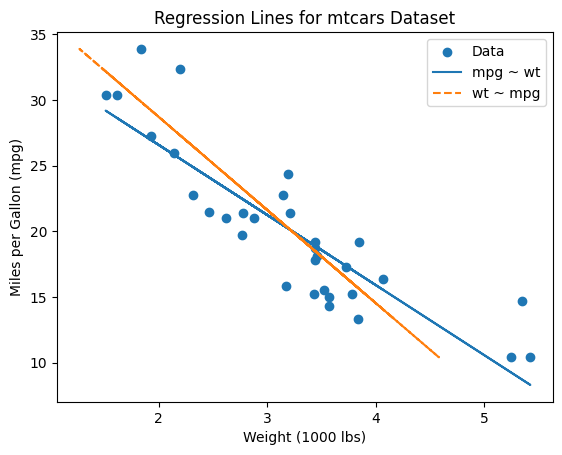


Interpretation:
Slope (mpg ~ wt): -5.344471572722678
→ mpg decreases as weight increases.

Slope (wt ~ mpg): -0.14086196987193306
→ weight decreases as mpg increases.
========== Problem 5 ==========
   speed  dist
0      4     2
1      4    10
2      7     4
3      7    22
4      8    16


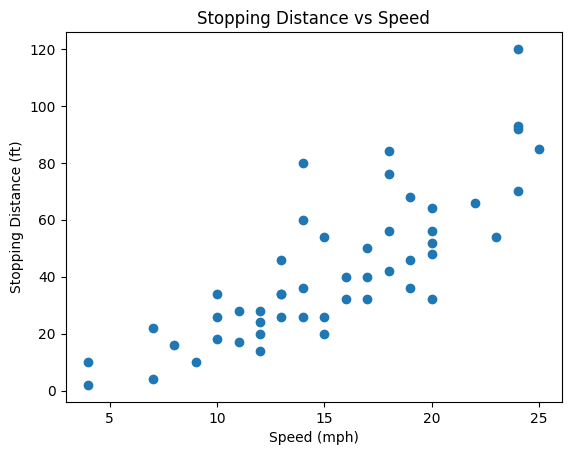


Quadratic Model Summary:
                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     47.14
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           5.85e-12
Time:                        09:08:14   Log-Likelihood:                -205.39
No. Observations:                  50   AIC:                             416.8
Df Residuals:                      47   BIC:                             422.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4701     

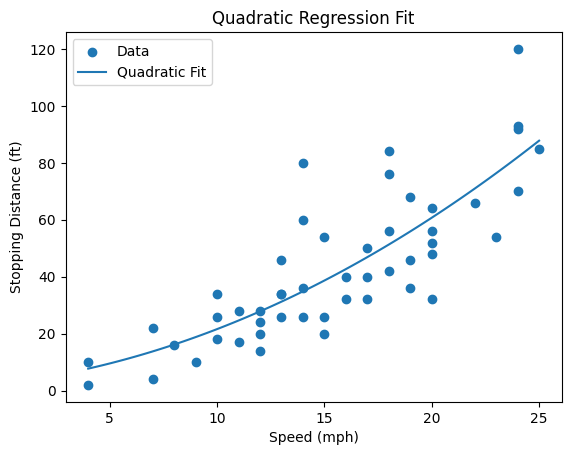


Predicted stopping distance:
At 45 mph: 245.98566711741606
At 80 mph: 715.2726801714723

Linear Model Summary:
                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.49e-12
Time:                        09:08:15   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------

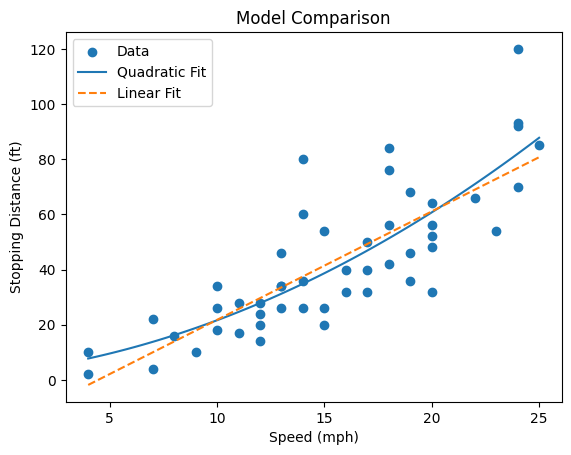


Model Comparison:
Quadratic model captures curvature better.
Linear model underestimates stopping distance at higher speeds.


In [4]:
# =========================
# Problem 4: mtcars Dataset
# =========================

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

print("========== Problem 4 ==========")

# Load dataset
mtcars = sm.datasets.get_rdataset("mtcars").data

# Display first few rows
print(mtcars.head())

# -------------------------
# (a) Regression: mpg ~ wt
# -------------------------
X1 = sm.add_constant(mtcars['wt'])
model1 = sm.OLS(mtcars['mpg'], X1).fit()

print("\nRegression Model: mpg ~ wt")
print(model1.summary())

# -------------------------
# (b) Regression: wt ~ mpg
# -------------------------
X2 = sm.add_constant(mtcars['mpg'])
model2 = sm.OLS(mtcars['wt'], X2).fit()

print("\nRegression Model: wt ~ mpg")
print(model2.summary())

# -------------------------
# (c) Plot both regressions
# -------------------------
plt.figure()

# Scatter plot
plt.scatter(mtcars['wt'], mtcars['mpg'], label="Data")

# Line 1: mpg ~ wt
plt.plot(mtcars['wt'], model1.predict(X1), label="mpg ~ wt")

# Line 2: wt ~ mpg (converted for plotting)
wt_pred = model2.predict(X2)
plt.plot(wt_pred, mtcars['mpg'], linestyle='dashed', label="wt ~ mpg")

plt.xlabel("Weight (1000 lbs)")
plt.ylabel("Miles per Gallon (mpg)")
plt.title("Regression Lines for mtcars Dataset")
plt.legend()
plt.show()

# -------------------------
# (d) Interpretation
# -------------------------
print("\nInterpretation:")
print("Slope (mpg ~ wt):", model1.params['wt'])
print("→ mpg decreases as weight increases.")

print("\nSlope (wt ~ mpg):", model2.params['mpg'])
print("→ weight decreases as mpg increases.")

# =========================
# Problem 5: cars Dataset
# =========================

print("========== Problem 5 ==========")
# Load dataset
cars = sm.datasets.get_rdataset("cars").data

# Display first rows
print(cars.head())

# -------------------------
# (a) Scatter Plot
# -------------------------
plt.figure()
plt.scatter(cars['speed'], cars['dist'])
plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (ft)")
plt.title("Stopping Distance vs Speed")
plt.show()

# -------------------------
# (b) Quadratic Model
# D = a0 + a1V + a2V^2
# -------------------------
cars['speed_sq'] = cars['speed']**2

X_quad = sm.add_constant(cars[['speed', 'speed_sq']])
quad_model = sm.OLS(cars['dist'], X_quad).fit()

print("\nQuadratic Model Summary:")
print(quad_model.summary())

# -------------------------
# (c) Plot with curve
# -------------------------
v = np.linspace(min(cars['speed']), max(cars['speed']), 100)

X_pred = sm.add_constant(pd.DataFrame({
    'speed': v,
    'speed_sq': v**2
}))

y_quad = quad_model.predict(X_pred)

plt.figure()
plt.scatter(cars['speed'], cars['dist'], label="Data")
plt.plot(v, y_quad, label="Quadratic Fit")
plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (ft)")
plt.title("Quadratic Regression Fit")
plt.legend()
plt.show()

# -------------------------
# (d) Predictions
# -------------------------
def predict_distance(v):
    return quad_model.predict([1, v, v**2])[0]

d_45 = predict_distance(45)
d_80 = predict_distance(80)

print("\nPredicted stopping distance:")
print("At 45 mph:", d_45)
print("At 80 mph:", d_80)

# -------------------------
# (e) Linear Model
# -------------------------
X_lin = sm.add_constant(cars['speed'])
lin_model = sm.OLS(cars['dist'], X_lin).fit()

print("\nLinear Model Summary:")
print(lin_model.summary())

# Plot comparison
y_lin = lin_model.predict(X_lin)

plt.figure()
plt.scatter(cars['speed'], cars['dist'], label="Data")
plt.plot(v, y_quad, label="Quadratic Fit")
plt.plot(cars['speed'], y_lin, linestyle='dashed', label="Linear Fit")

plt.xlabel("Speed (mph)")
plt.ylabel("Stopping Distance (ft)")
plt.title("Model Comparison")
plt.legend()
plt.show()

# -------------------------
# Comparison Interpretation
# -------------------------
print("\nModel Comparison:")
print("Quadratic model captures curvature better.")
print("Linear model underestimates stopping distance at higher speeds.")